# Классификация IC50 относительно медианного значения

В этом ноутбуке решается задача бинарной классификации:

- класс `1` -> значение `IC50, mM` выше медианного значения выборки
- класс `0` -> значение `IC50, mM` ниже либо равно медианному значению выборки

Для обучения используются молекулярные дескрипторы после предобработки признаков.

Из признакового пространства заранее исключены:

- служебные столбцы
- `IC50, mM`
- `CC50, mM`
- `SI`

Это необходимо, чтобы не допустить утечки данных.

## Импорты

In [73]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import pandas as pd

# Разделение данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Метрики классификации
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Визуализация
import matplotlib.pyplot as plt

# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    get_dataset_overview,
    load_coursework_dataset,
)

# Конфигурация проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_IC50,
    TEST_SIZE,
)

# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_ic50_above_median_target,
    preprocess_features,
)

# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import (
    get_classification_models,
)

# Запуск экспериментов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_classification_experiment,
)

# Графики
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_classification_results,
    plot_feature_importance,
)

warnings.filterwarnings("ignore")

## Загрузка данных

Загрузим исходный датасет и проверим его базовую структуру.

In [74]:
df = load_coursework_dataset()

print(f"Размер датасета: {df.shape}")
print(get_dataset_overview(df))

df.head()

Размер датасета: (1001, 214)
{'rows': 1001, 'columns': 214, 'missing_values': 36, 'duplicated_rows': 0}


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Подготовка признаков и целевой переменной

Сформируем матрицу признаков `X` и бинарную целевую переменную `y`.

Целевая переменная строится по правилу:

```text
IC50, mM > median(IC50, mM)

Примечание:
1 -> значение IC50 выше медианы
0 -> значение IC50 ниже либо равно медиане
```

In [75]:
X = build_features(df)

y = build_ic50_above_median_target(df)

ic50_median = df[TARGET_IC50].median()

print(f"Размер исходной матрицы признаков X: {X.shape}")

print(f"Размер целевой переменной y: {y.shape}")

print(f"Медианное значение {TARGET_IC50}: {ic50_median:.4f}")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Медианное значение IC50, mM: 46.5852


## Распределение классов

Проверим, насколько сбалансированы классы.

Так как целевая переменная построена относительно медианы, ожидается достаточно равномерное распределение классов.

In [76]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["share"] = class_distribution["count"] / class_distribution["count"].sum()

class_distribution

,class,count,share
0,0,501,0.5005
1,1,500,0.4995


## Предобработка признаков

По итогам EDA выполним очистку признакового пространства.

Удалим:

- константные признаки, у которых во всех строках одно и то же значение
- почти константные признаки, где одно значение встречается минимум в 99% строк
- сильно коррелирующие признаки, если абсолютная Spearman-корреляция между двумя признаками не ниже 0.90

Целевую переменную на этом этапе не изменяем.

In [77]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")

print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [78]:
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Подготовка моделей классификации

Для сравнения используем несколько моделей бинарной классификации:

- DummyClassifier
- Logistic Regression
- KNN
- SVC
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

`DummyClassifier` необходим как базовая модель для проверки, действительно ли остальные модели находят полезные закономерности в данных.

In [79]:
classification_models = get_classification_models()

classification_models.keys()

dict_keys(['dummy_most_frequent', 'logistic_regression', 'knn', 'svc_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Запуск эксперимента

Обучим модели на предобработанных признаках.

Для оценки качества используем:

- `accuracy`
- `balanced_accuracy`
- `precision`
- `recall`
- `f1`
- `roc_auc`

Основной метрикой будем считать `F1`, так как она учитывает баланс между precision и recall.

In [80]:
ic50_classification_results, ic50_fitted_models = run_classification_experiment(
    X=X_clean,
    y=y,
    models=classification_models,
)

ic50_classification_results["feature_set"] = "preprocessed_features"
ic50_classification_results["target"] = "ic50_above_median"

ic50_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,catboost,0.732680,0.012472,800,201,4.076365,0.726368,0.726683,0.699115,0.79,0.741784,0.766881,preprocessed_features,ic50_above_median
1,hist_gradient_boosting,0.719594,0.008581,800,201,1.817387,0.711443,0.711733,0.687500,0.77,0.726415,0.756881,preprocessed_features,ic50_above_median
2,knn,0.702611,0.026201,800,201,0.156449,0.716418,0.716485,0.708738,0.73,0.719212,0.766040,preprocessed_features,ic50_above_median
3,random_forest,0.734910,0.008539,800,201,0.742296,0.691542,0.692030,0.658333,0.79,0.718182,0.775000,preprocessed_features,ic50_above_median
4,svc_rbf,0.728992,0.023947,800,201,0.257004,0.701493,0.701733,0.681818,0.75,0.714286,0.739950,preprocessed_features,ic50_above_median
5,extra_trees,0.735552,0.016717,800,201,0.541524,0.686567,0.687030,0.655462,0.78,0.712329,0.765693,preprocessed_features,ic50_above_median
6,logistic_regression,0.676142,0.027891,800,201,1.579157,0.686567,0.686881,0.663717,0.75,0.704225,0.745990,preprocessed_features,ic50_above_median
7,dummy_most_frequent,0.000000,0.000000,800,201,1.959016,0.502488,0.500000,0.000000,0.00,0.000000,0.500000,preprocessed_features,ic50_above_median


## Сохранение метрик

Сохраним таблицу с метриками в директорию `outputs/metrics`.

In [81]:
ic50_classification_results.to_csv(
    METRICS_DIR / "classification_ic50_above_median_metrics.csv",
    index=False,
)

ic50_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,catboost,0.732680,0.012472,800,201,4.076365,0.726368,0.726683,0.699115,0.79,0.741784,0.766881,preprocessed_features,ic50_above_median
1,hist_gradient_boosting,0.719594,0.008581,800,201,1.817387,0.711443,0.711733,0.687500,0.77,0.726415,0.756881,preprocessed_features,ic50_above_median
2,knn,0.702611,0.026201,800,201,0.156449,0.716418,0.716485,0.708738,0.73,0.719212,0.766040,preprocessed_features,ic50_above_median
3,random_forest,0.734910,0.008539,800,201,0.742296,0.691542,0.692030,0.658333,0.79,0.718182,0.775000,preprocessed_features,ic50_above_median
4,svc_rbf,0.728992,0.023947,800,201,0.257004,0.701493,0.701733,0.681818,0.75,0.714286,0.739950,preprocessed_features,ic50_above_median
5,extra_trees,0.735552,0.016717,800,201,0.541524,0.686567,0.687030,0.655462,0.78,0.712329,0.765693,preprocessed_features,ic50_above_median
6,logistic_regression,0.676142,0.027891,800,201,1.579157,0.686567,0.686881,0.663717,0.75,0.704225,0.745990,preprocessed_features,ic50_above_median
7,dummy_most_frequent,0.000000,0.000000,800,201,1.959016,0.502488,0.500000,0.000000,0.00,0.000000,0.500000,preprocessed_features,ic50_above_median


## График сравнения моделей

Построим график сравнения моделей по метрике `F1`.

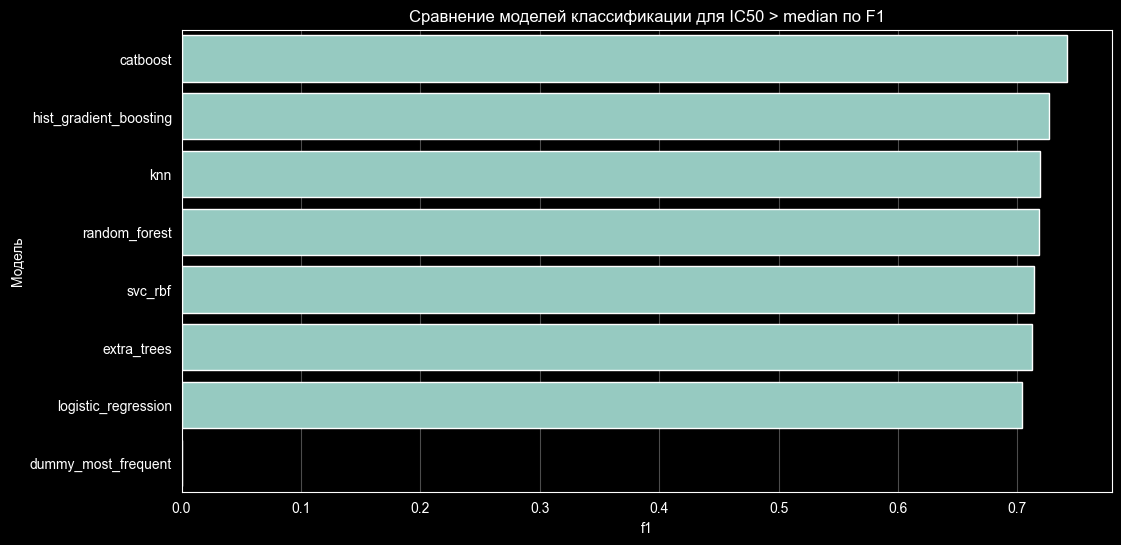

In [82]:
plot_classification_results(
    results_df=ic50_classification_results,
    metric="f1",
    title="Сравнение моделей классификации для IC50 > median по F1",
)

## Дополнительное сравнение по ROC-AUC

ROC-AUC показывает, насколько хорошо модель ранжирует объекты по вероятности положительного класса.

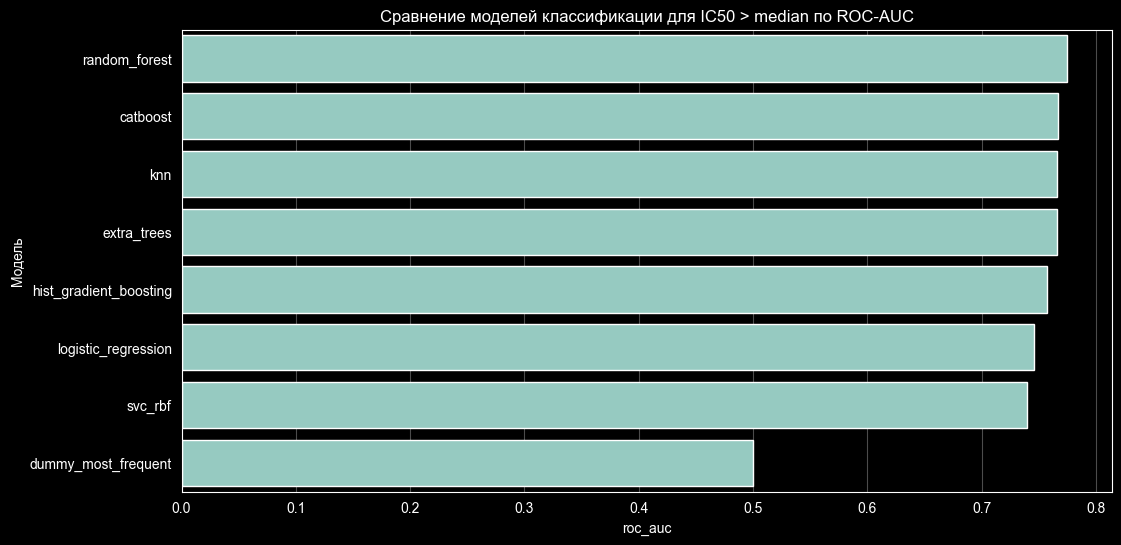

In [83]:
plot_classification_results(
    results_df=ic50_classification_results,
    metric="roc_auc",
    title="Сравнение моделей классификации для IC50 > median по ROC-AUC",
)

## Выбор лучшей модели

Лучшей моделью считаем модель с максимальным значением `F1`.

Дополнительно посмотрим:

- `accuracy`
- `balanced_accuracy`
- `precision`
- `recall`
- `roc_auc`

In [84]:
best_result = ic50_classification_results.iloc[0]

best_result

model                             catboost
cv_f1_mean                         0.73268
cv_f1_std                         0.012472
train_rows                             800
test_rows                              201
fit_time_sec                      4.076365
accuracy                          0.726368
balanced_accuracy                 0.726683
precision                         0.699115
recall                                0.79
f1                                0.741784
roc_auc                           0.766881
feature_set          preprocessed_features
target                   ic50_above_median
Name: 0, dtype: object

In [85]:
best_model_name = best_result["model"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_result['feature_set']}")
print(f"Целевая переменная: {best_result['target']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Balanced accuracy: {best_result['balanced_accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")
print(f"F1: {best_result['f1']:.4f}")
print(f"ROC-AUC: {best_result['roc_auc']:.4f}")

Лучшая модель: catboost
Набор признаков: preprocessed_features
Целевая переменная: ic50_above_median
Accuracy: 0.7264
Balanced accuracy: 0.7267
Precision: 0.6991
Recall: 0.7900
F1: 0.7418
ROC-AUC: 0.7669


## Получение лучшей обученной модели

Получим лучшую обученную модель из словаря `ic50_fitted_models`.

In [86]:
best_model = ic50_fitted_models[best_model_name]

best_model

CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

## Предсказания лучшей модели

Повторим такое же разбиение на train/test, которое используется внутри эксперимента.

Это нужно, чтобы получить предсказания лучшей модели на той же тестовой выборке.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "classification_ic50_above_median_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
423,1,1
818,0,0
73,0,0
446,0,1
251,1,1


## Посмотрим precision, recall и F1 отдельно по каждому классу

In [88]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "IC50 <= median",
            "IC50 > median",
        ],
    )
)

                precision    recall  f1-score   support

IC50 <= median       0.76      0.66      0.71       101
 IC50 > median       0.70      0.79      0.74       100

      accuracy                           0.73       201
     macro avg       0.73      0.73      0.73       201
  weighted avg       0.73      0.73      0.73       201



## Матрица ошибок

Построим матрицу ошибок для лучшей модели.

Она показывает:
- сколько объектов каждого класса модель определила верно
- сколько объектов были ошибочно отнесены к другому классу

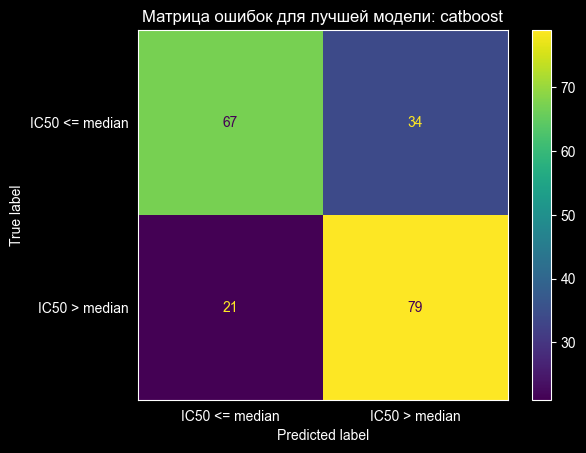

In [89]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "IC50 <= median",
        "IC50 > median",
    ],
)

plt.title(f"Матрица ошибок для лучшей модели: {best_model_name}")
plt.grid(False)
plt.show()

## Важность признаков

Если лучшая модель поддерживает расчет важности признаков, посмотрим топ наиболее значимых дескрипторов.

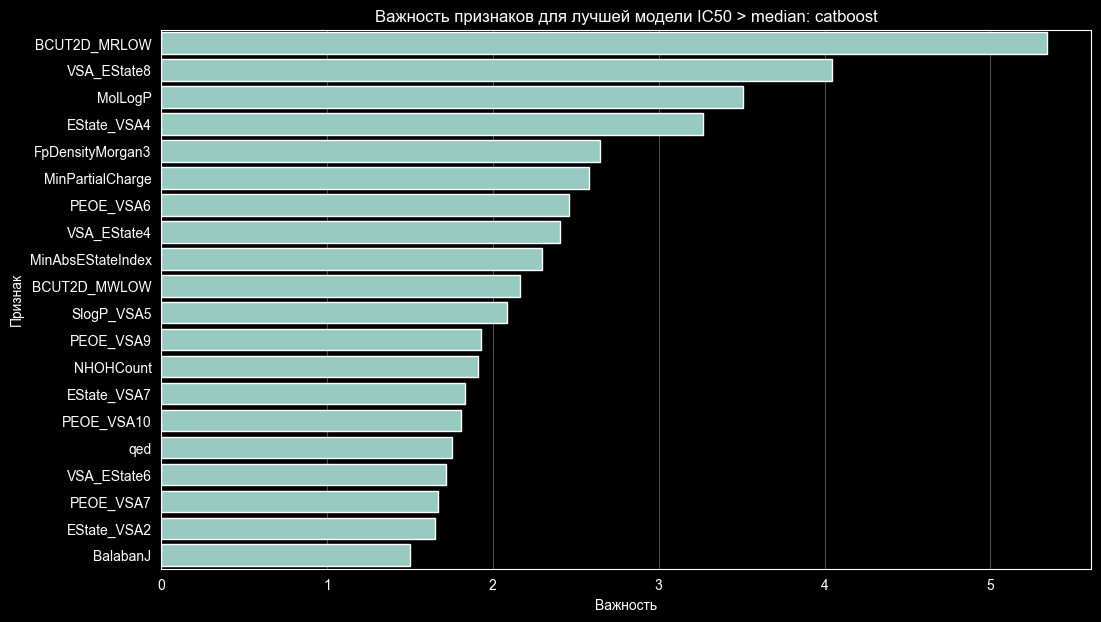

In [90]:
try:
    ic50_feature_importance = plot_feature_importance(
        model=best_model,
        feature_names=X_clean.columns.tolist(),
        top_n=20,
        title=f"Важность признаков для лучшей модели IC50 > median: {best_model_name}",
    )

    ic50_feature_importance.to_csv(
        METRICS_DIR / "classification_ic50_above_median_feature_importance.csv",
        index=False,
    )

    ic50_feature_importance.head(20)

except ValueError as error:
    print(error)

# Вывод по задаче классификации IC50 > median

В этом ноутбуке решалась задача бинарной классификации
в целях определения, превышает ли значение `IC50, mM` медианное значение выборки.

Медианное значение целевой переменной:
```
IC50, mM = 46.5852
```

Целевая переменная была сформирована таким образом:
```
0 -> IC50 <= median
1 -> IC50 > median
```

Распределение классов получилось практически сбалансированным:
```
0 -> 501 объект, доля 0.5005
1 -> 500 объектов, доля 0.4995
```

Это хороший признак для задачи классификации,
так как модель не обучается на сильно перекошенных классах, а метрики accuracy, balanced_accuracy и F1
можно интерпретировать достаточно уверенно.

Перед обучением была выполнена предобработка признаков по итогам EDA:
```
Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76
```

Для сравнения были обучены несколько моделей бинарной классификации:
```
DummyClassifier
Logistic Regression
KNN
SVC
Random Forest
Extra Trees
HistGradientBoosting
CatBoost
```

Лучшей моделью по итогам сравнения стала:
```
CatBoostClassifier
```

Основные метрики лучшей модели:
```
Accuracy: 0.7264
Balanced accuracy: 0.7267
Precision: 0.6991
Recall: 0.7900
F1: 0.7418
ROC-AUC: 0.7669
```

Модель значительно лучше базовой константной модели DummyClassifier, у которой F1 = 0.
Это означает, что модель действительно находит полезные закономерности в молекулярных дескрипторах,
а не просто предсказывает один наиболее частый класс.

По отчету классификации видно, что модель лучше находит соединения с `IC50 > median`:
```
IC50 <= median:
precision = 0.76
recall = 0.66
f1-score = 0.71

IC50 > median:
precision = 0.70
recall = 0.79
f1-score = 0.74
```

Модель чаще пропускает часть объектов класса IC50 <= median,
но лучше обнаруживает объекты, у которых IC50 выше медианы.

Матрица ошибок подтверждает этот вывод:
```
         predicted 0    predicted 1
true 0       67             34
true 1       21             79
```

Модель правильно классифицировала:
```
67 объектов класса IC50 <= median
79 объектов класса IC50 > median
```

Ошибки:
```
34 объекта с IC50 <= median были ошибочно отнесены к классу IC50 > median
21 объект с IC50 > median был ошибочно отнесен к классу IC50 <= median
```

Наиболее важными признаками для лучшей модели оказались:
```
BCUT2D_MRLOW
VSA_EState8
MolLogP
EState_VSA4
FpDensityMorgan3
MinPartialCharge
PEOE_VSA6
VSA_EState4
MinAbsEStateIndex
BCUT2D_MWLOW
```

### Итог

Для задачи классификации `IC50 > median` в качестве основной модели можно выбрать `CatBoostClassifier`,
обученный на предобработанных признаках.
Модель показывает умеренно хорошее качество: `F1 = 0.7418`, `ROC-AUC = 0.7669`, что заметно выше базового уровня.
При этом качество не идеальное, поэтому модель стоит рассматривать как рабочий baseline для классификации,
а не как финальную production-модель без дополнительной настройки гиперпараметров.